In [6]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from scipy.linalg import eigh
driver = PySCFDriver(
    atom="H 1.4 0 0; H 0 0 0",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)
problem = driver.run()
hamiltonian = problem.hamiltonian
# 获得二次量子化后的分子哈密顿量
second_q_op = hamiltonian.second_q_op()
mapper = JordanWignerMapper()
# 映射为量子比特哈密顿量
qubit_op_ham = mapper.map(second_q_op)
# 计算哈密顿量的本征值和本征向量
ham_matrix = qubit_op_ham.to_matrix()
eigenvalues, eigenvectors = eigh(ham_matrix)
# 获得基态的本征值和本征向量
exact_energy = eigenvalues[0]
exact_state = eigenvectors[:, 0]

将精确基态波函数 用 4个量子比特组成的基态表示出来 并画成柱状图

In [7]:
from jax._src import state
from qiskit.quantum_info import Statevector,state_fidelity
exact_state_vector = Statevector(exact_state)

In [8]:
fidilities = [state_fidelity(exact_state_vector, Statevector.from_label(f"{i:04b}")) for i in range(16)]

In [9]:
binary_strings = [f"{i:04b}" for i in range(16)]
print(binary_strings)

['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


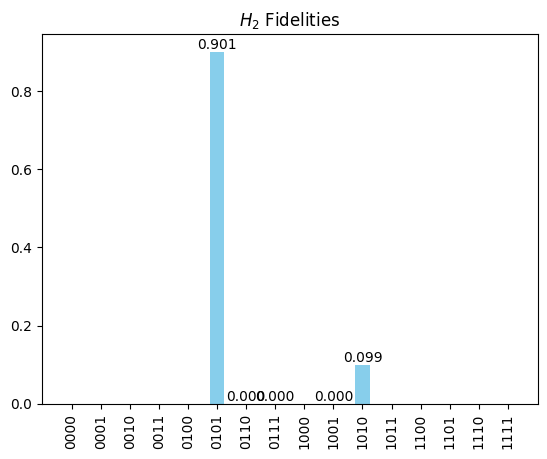

In [10]:
import matplotlib.pyplot as plt
fidilitiescategories = binary_strings
values = fidilities
plt.title("$H_2$ Fidelities ")
# 创建条形图，通过 width 参数拉宽不同 bar 的间距
plt.bar(fidilitiescategories, values, color='skyblue', width=0.5)
# 设置横坐标标签竖向排列
plt.xticks(rotation='vertical')
# 在每个条形图上方标注数值，数值为 0 时不标出，数值精确到后三位
for i in range(len(fidilitiescategories)):
    if values[i] != 0:
        plt.text(i, values[i], f'{values[i]:.3f}', ha='center', va='bottom')


In [14]:
ham_matrix.shape

(16, 16)

In [16]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

In [17]:
problem = driver.run()
print(problem)

In [18]:
hamiltonian = problem.hamiltonian

coefficients = hamiltonian.electronic_integrals
print(coefficients.alpha)

Polynomial Tensor
 "+-":
array([[-1.25633907e+00, -3.32709795e-16],
       [-2.65367007e-16, -4.71896007e-01]])
 "++--":
array([6.75710155e-01, 2.20471299e-16, 1.80931200e-01, 6.64581730e-01,
       3.16757645e-16, 6.98573723e-01])


In [23]:
hamiltonian.second_q_op()

FermionicOp({'+_0 -_0': -1.2563390730032495, '+_1 -_1': -0.4718960072811421, '+_2 -_2': -1.2563390730032495, '+_3 -_3': -0.4718960072811421, '+_0 +_0 -_0 -_0': 0.33785507740175813, '+_0 +_1 -_1 -_0': 0.3322908651276482, '+_0 +_2 -_2 -_0': 0.33785507740175813, '+_0 +_3 -_3 -_0': 0.3322908651276482, '+_0 +_0 -_1 -_1': 0.0904655998921157, '+_0 +_1 -_0 -_1': 0.0904655998921157, '+_0 +_2 -_3 -_1': 0.0904655998921157, '+_0 +_3 -_2 -_1': 0.0904655998921157, '+_1 +_0 -_1 -_0': 0.0904655998921157, '+_1 +_1 -_0 -_0': 0.0904655998921157, '+_1 +_2 -_3 -_0': 0.0904655998921157, '+_1 +_3 -_2 -_0': 0.0904655998921157, '+_1 +_0 -_0 -_1': 0.3322908651276482, '+_1 +_1 -_1 -_1': 0.34928686136600906, '+_1 +_2 -_2 -_1': 0.3322908651276482, '+_1 +_3 -_3 -_1': 0.34928686136600906, '+_2 +_0 -_0 -_2': 0.33785507740175813, '+_2 +_1 -_1 -_2': 0.3322908651276482, '+_2 +_2 -_2 -_2': 0.33785507740175813, '+_2 +_3 -_3 -_2': 0.3322908651276482, '+_2 +_0 -_1 -_3': 0.0904655998921157, '+_2 +_1 -_0 -_3': 0.0904655998921

In [19]:
second_q_op = hamiltonian.second_q_op()
print(second_q_op)

Fermionic Operator
number spin orbitals=4, number terms=36
  -1.2563390730032495 * ( +_0 -_0 )
+ -0.4718960072811421 * ( +_1 -_1 )
+ -1.2563390730032495 * ( +_2 -_2 )
+ -0.4718960072811421 * ( +_3 -_3 )
+ 0.33785507740175813 * ( +_0 +_0 -_0 -_0 )
+ 0.3322908651276482 * ( +_0 +_1 -_1 -_0 )
+ 0.33785507740175813 * ( +_0 +_2 -_2 -_0 )
+ 0.3322908651276482 * ( +_0 +_3 -_3 -_0 )
+ 0.0904655998921157 * ( +_0 +_0 -_1 -_1 )
+ 0.0904655998921157 * ( +_0 +_1 -_0 -_1 )
+ 0.0904655998921157 * ( +_0 +_2 -_3 -_1 )
+ 0.0904655998921157 * ( +_0 +_3 -_2 -_1 )
+ 0.0904655998921157 * ( +_1 +_0 -_1 -_0 )
+ 0.0904655998921157 * ( +_1 +_1 -_0 -_0 )
+ 0.0904655998921157 * ( +_1 +_2 -_3 -_0 )
+ 0.0904655998921157 * ( +_1 +_3 -_2 -_0 )
+ 0.3322908651276482 * ( +_1 +_0 -_0 -_1 )
+ 0.34928686136600906 * ( +_1 +_1 -_1 -_1 )
+ 0.3322908651276482 * ( +_1 +_2 -_2 -_1 )
+ 0.34928686136600906 * ( +_1 +_3 -_3 -_1 )
+ 0.33785507740175813 * ( +_2 +_0 -_0 -_2 )
+ 0.3322908651276482 * ( +_2 +_1 -_1 -_2 )
+ 0.33785507740175

In [ ]:
second_q_op.to

FermionicOp({'+_0 -_0': -1.2563390730032495, '+_1 -_1': -0.4718960072811421, '+_2 -_2': -1.2563390730032495, '+_3 -_3': -0.4718960072811421, '+_0 +_0 -_0 -_0': 0.33785507740175813, '+_0 +_1 -_1 -_0': 0.3322908651276482, '+_0 +_2 -_2 -_0': 0.33785507740175813, '+_0 +_3 -_3 -_0': 0.3322908651276482, '+_0 +_0 -_1 -_1': 0.0904655998921157, '+_0 +_1 -_0 -_1': 0.0904655998921157, '+_0 +_2 -_3 -_1': 0.0904655998921157, '+_0 +_3 -_2 -_1': 0.0904655998921157, '+_1 +_0 -_1 -_0': 0.0904655998921157, '+_1 +_1 -_0 -_0': 0.0904655998921157, '+_1 +_2 -_3 -_0': 0.0904655998921157, '+_1 +_3 -_2 -_0': 0.0904655998921157, '+_1 +_0 -_0 -_1': 0.3322908651276482, '+_1 +_1 -_1 -_1': 0.34928686136600906, '+_1 +_2 -_2 -_1': 0.3322908651276482, '+_1 +_3 -_3 -_1': 0.34928686136600906, '+_2 +_0 -_0 -_2': 0.33785507740175813, '+_2 +_1 -_1 -_2': 0.3322908651276482, '+_2 +_2 -_2 -_2': 0.33785507740175813, '+_2 +_3 -_3 -_2': 0.3322908651276482, '+_2 +_0 -_1 -_3': 0.0904655998921157, '+_2 +_1 -_0 -_3': 0.0904655998921

FermionicOp({'+_0 -_0': -1.2563390730032495, '+_1 -_1': -0.4718960072811421, '+_2 -_2': -1.2563390730032495, '+_3 -_3': -0.4718960072811421, '+_0 +_0 -_0 -_0': 0.33785507740175813, '+_0 +_1 -_1 -_0': 0.3322908651276482, '+_0 +_2 -_2 -_0': 0.33785507740175813, '+_0 +_3 -_3 -_0': 0.3322908651276482, '+_0 +_0 -_1 -_1': 0.0904655998921157, '+_0 +_1 -_0 -_1': 0.0904655998921157, '+_0 +_2 -_3 -_1': 0.0904655998921157, '+_0 +_3 -_2 -_1': 0.0904655998921157, '+_1 +_0 -_1 -_0': 0.0904655998921157, '+_1 +_1 -_0 -_0': 0.0904655998921157, '+_1 +_2 -_3 -_0': 0.0904655998921157, '+_1 +_3 -_2 -_0': 0.0904655998921157, '+_1 +_0 -_0 -_1': 0.3322908651276482, '+_1 +_1 -_1 -_1': 0.34928686136600906, '+_1 +_2 -_2 -_1': 0.3322908651276482, '+_1 +_3 -_3 -_1': 0.34928686136600906, '+_2 +_0 -_0 -_2': 0.33785507740175813, '+_2 +_1 -_1 -_2': 0.3322908651276482, '+_2 +_2 -_2 -_2': 0.33785507740175813, '+_2 +_3 -_3 -_2': 0.3322908651276482, '+_2 +_0 -_1 -_3': 0.0904655998921157, '+_2 +_1 -_0 -_3': 0.0904655998921